In [ ]:
# https://www.kaggle.com/competitions/titanic

In [25]:
from inspect import FrameInfo
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

font_path = '/content/drive/MyDrive/kwukdt/data-analysis/data-pre-processing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font', family = 'NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = pd.read_csv('/content/drive/MyDrive/kwukdt/data-analysis/data-pre-processing/train.csv')
print(titanic.shape)
titanic.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [27]:
import numpy as np

print(np.nan == np.nan)
print(np.nan == 0)
print(np.nan == '')
print(np.nan == None)

print(pd.isnull(np.nan))
print(pd.notnull(np.nan))

s = pd.Series([1, np.nan, 3, None, 5])
s

False
False
False
False
True
False


,0
0,1.0
1,NaN
2,3.0
3,NaN
4,5.0


In [28]:
titanic.info()

missing_count = titanic.isnull().sum()
print(f'\n{missing_count[missing_count>0]}')

missing_ratio = (titanic.isnull().sum()/len(titanic) * 100).round(1)
print(f'\n{missing_ratio[missing_ratio>0]}')

total_missing = titanic.isnull().sum().sum()
print(f'\n{total_missing[total_missing>0]}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Age         177
Cabin       687
Embarked      2
dtype: int64

Age         19.9
Cabin       77.1
Embarked     0.2
dtype: float64

[866]


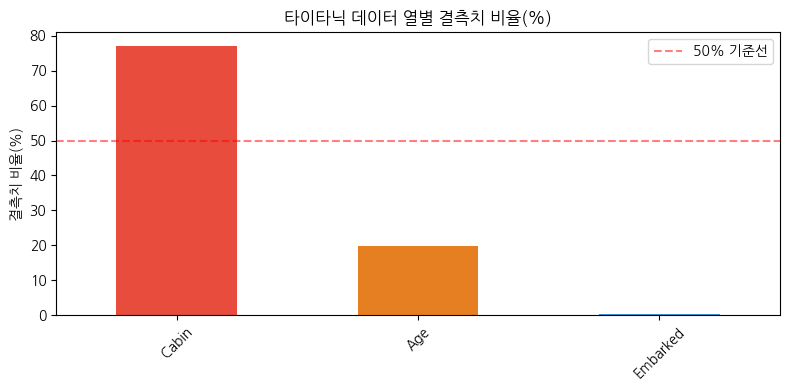

In [31]:
missing_ratio = titanic.isnull().mean() * 100
missing_ratio = missing_ratio[missing_ratio>0].sort_values(ascending=False)
missing_ratio

plt.figure(figsize=(8, 4))
missing_ratio.plot(kind='bar', color=['#E74C3C', '#E67E22', '#3498DB'])
plt.title('타이타닉 데이터 열별 결측치 비율(%)')
plt.ylabel('결측치 비율(%)')
plt.xticks(rotation=45)
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% 기준선')
plt.legend()
plt.tight_layout()
plt.show()

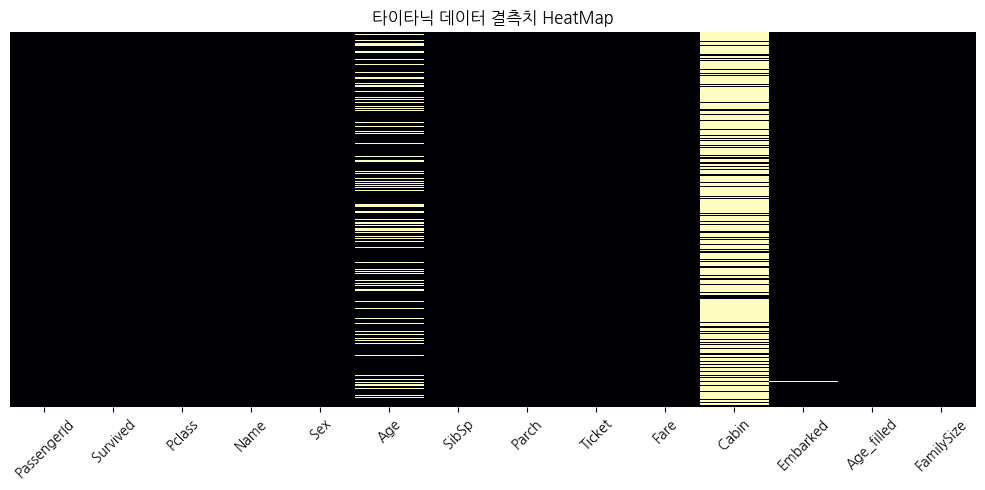

In [91]:
plt.figure(figsize=(10, 5))
sns.heatmap(titanic.isnull(),
            cbar=False,
            cmap='magma',
            yticklabels=False)
plt.title('타이타닉 데이터 결측치 HeatMap')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [43]:
from itertools import groupby
print(titanic['Embarked'].mode())
titanic['Embarked'].fillna('S')

mean_age = titanic['Age'].mean().round(2)
median_age = titanic['Age'].median()
print(mean_age, median_age)
titanic['Age_filled'] = titanic['Age'].fillna(median_age)
print(f'대체 전 결측치: {titanic['Age'].isnull().sum()}')
print(f'대체 후 결측치: {titanic['Age_filled'].isnull().sum()}')

titanic['Age_filled'] = titanic.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)
print(titanic.groupby(['Sex', 'Pclass'])['Age'].median())

0    S
Name: Embarked, dtype: object
29.7 28.0
대체 전 결측치: 177
대체 후 결측치: 0
Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64


In [53]:
daily_passengers = pd.Series(
    [100, np.nan, np.nan, 130, np.nan, 150],
    index=pd.date_range('2026-01-01', periods=6)
)
print(f'------- 원본 -------\n{daily_passengers}')
print(f'\n------- ffill -------\n{daily_passengers.ffill()}')
print(f'\n------- bfill -------\n{daily_passengers.bfill()}')
print(f'\n------- interpolate -------\n{daily_passengers.interpolate()}')

------- 원본 -------
2026-01-01    100.0
2026-01-02      NaN
2026-01-03      NaN
2026-01-04    130.0
2026-01-05      NaN
2026-01-06    150.0
Freq: D, dtype: float64

------- ffill -------
2026-01-01    100.0
2026-01-02    100.0
2026-01-03    100.0
2026-01-04    130.0
2026-01-05    130.0
2026-01-06    150.0
Freq: D, dtype: float64

------- bfill -------
2026-01-01    100.0
2026-01-02    130.0
2026-01-03    130.0
2026-01-04    130.0
2026-01-05    150.0
2026-01-06    150.0
Freq: D, dtype: float64

------- interpolate -------
2026-01-01    100.0
2026-01-02    110.0
2026-01-03    120.0
2026-01-04    130.0
2026-01-05    140.0
2026-01-06    150.0
Freq: D, dtype: float64


In [67]:
df_dropped = titanic.dropna()
print(f"원본: {titanic.shape}")

print(f"\ndropna 후: {df_dropped.shape}")

df_no_deck = titanic.drop(columns=['Cabin'])
print(f'\nCabin 칼럼 삭제 후: {df_no_deck.shape}')

df_age_only = titanic.dropna(subset=['Age'])
print(f'\nAge 칼럼 삭제 후: {df_age_only.shape}')

df_all = titanic.dropna(how='all')
print(f"\n모든 칼럼이 NaN인 행만 삭제 후: {df_all.shape}")

df_thresh = titanic.dropna(thresh=10)
print(f"\n유효 값(=정상적이 값)이 10개 미만인 행 삭제: {df_thresh.shape}")

원본: (891, 13)

dropna 후: (183, 13)

Cabin 칼럼 삭제 후: (891, 12)

Age 칼럼 삭제 후: (714, 13)

모든 칼럼이 NaN인 행만 삭제 후: (891, 13)

유효 값이 10개 미만인 행 삭제: (891, 13)


In [74]:
s = pd.Series([10, np.nan, 30, np.nan, 50])
print(s + 5)

print(s.sum())
print(s.mean())

print(s.sum(skipna=False))
print(s.mean(skipna=False))

titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1
titanic['Test'] = titanic['Age'] + titanic['Fare']
print(titanic['Test'].isnull().sum())

titanic = titanic.drop(columns=['Test'])

0    15.0
1     NaN
2    35.0
3     NaN
4    55.0
dtype: float64
90.0
30.0
nan
nan
177


In [81]:
df = pd.DataFrame({'name':['Alice', 'Bob'], 'age':[25, 30]})
df.loc[0, 'age'] = np.nan
print(df.dtypes)
print(f'\n{df}')

df2 = pd.DataFrame({'name':['Alice', 'Bob'], 'age':pd.array([25, 30], dtype='Int64')})
df.loc[0, 'age'] = np.nan
print(f'\n{df.dtypes}')
print(f'\n{df}')

print(True and np.nan)
print(False and np.nan)

print(True and pd.NA)
print(False and pd.NA)

name     object
age     float64
dtype: object

    name   age
0  Alice   NaN
1    Bob  30.0

name     object
age     float64
dtype: object

    name   age
0  Alice   NaN
1    Bob  30.0
nan
False
<NA>
False


In [90]:
titanic_clean = titanic.copy()
titanic_clean = titanic_clean.drop(columns=['Cabin'])
titanic_clean['Age'] = titanic_clean.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(titanic_clean['Embarked'].mode()[0])

print(f'결측치 전처리 후 최종 결과')
print(titanic_clean.isnull().sum()[titanic_clean.isnull().sum() > 0])

print(f'원본 shape: {titanic.shape}')
print(f'전처리 후 shape: {titanic_clean.shape}')

결측치 전처리 후 최종 결과
Series([], dtype: int64)
원본 shape: (891, 14)
전처리 후 shape: (891, 13)


In [93]:
age_missing = titanic[titanic['Age'].isnull()]
age_missing[['SibSp', 'Parch', 'Sex', 'Pclass']]

age_missing[['SibSp', 'Parch', 'Sex', 'Pclass']].describe()
print(age_missing['Sex'].value_counts())
print(age_missing['Pclass'].value_counts())
print(age_missing['SibSp'].value_counts())
print(age_missing['Parch'].value_counts())

Sex
male      124
female     53
Name: count, dtype: int64
Pclass
3    136
1     30
2     11
Name: count, dtype: int64
SibSp
0    137
1     26
8      7
3      4
2      3
Name: count, dtype: int64
Parch
0    157
2     12
1      8
Name: count, dtype: int64


In [94]:
# 'Age' 결측치 중 가족과 함께 탑승하지 않은 3등석 남자 승객 다수

condition = (
    (titanic['Sex'] == 'male') &
    (titanic['Pclass'] == 3) &
    (titanic['SibSp'] == 0) &
    (titanic['Parch'] == 0)
)
group_mean_age = titanic[condition]['Age'].mean()

In [95]:
titanic.loc[condition & titanic['Age'].isnull(), 'Age'] = group_mean_age